Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
MAKLUMAT SISTEM
PyTorch       : 2.11.0+cu128
CUDA tersedia : True
Peranti YOLO  : 0
Nama GPU      : Tesla T4
Model pralatih berjaya dimuatkan: yolo11n.pt
Dataset latihan                 : coco8.yaml
Epochs                          : 5
Image size                      : 640
Batch size                      : 8
Ultralytics 8.4.145 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=fli

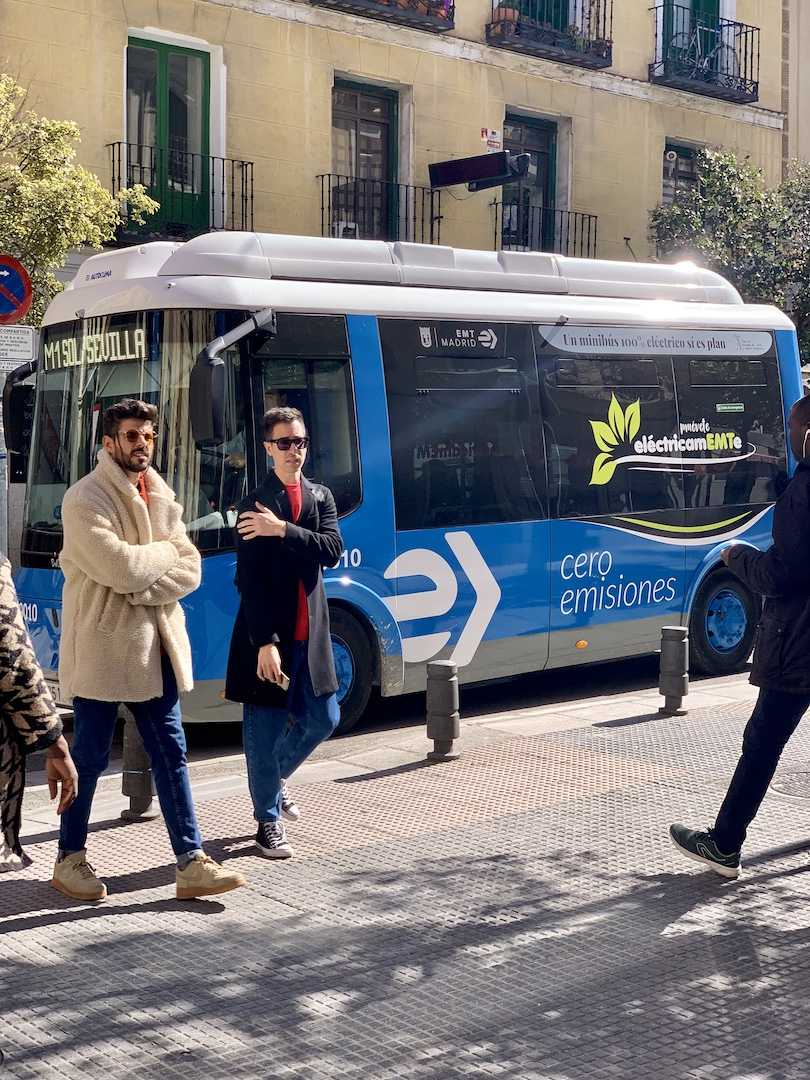

Confidence threshold: 0.25
IoU threshold       : 0.45
Jumlah objek        : 5


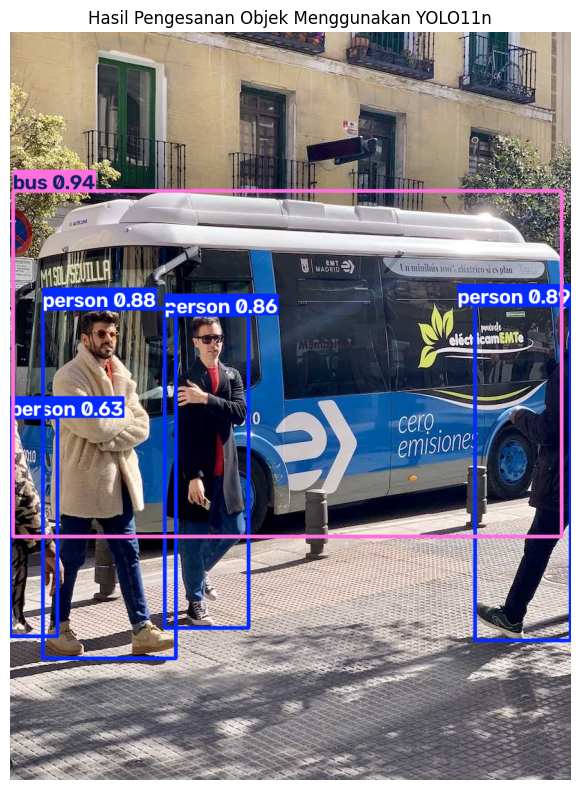

BUTIRAN PENGESANAN
01. bus          | keyakinan=94.06% | kotak=(4.1, 229.4, 796.2, 728.6)
02. person       | keyakinan=88.97% | kotak=(671.1, 394.8, 809.8, 878.6)
03. person       | keyakinan=87.88% | kotak=(47.4, 399.5, 239.3, 904.2)
04. person       | keyakinan=85.70% | kotak=(223.2, 408.7, 344.4, 860.4)
05. person       | keyakinan=62.67% | kotak=(0.0, 556.3, 68.6, 872.0)
Confidence 0.10 -> 6 objek
Confidence 0.25 -> 5 objek
Confidence 0.50 -> 5 objek
Confidence 0.75 -> 4 objek


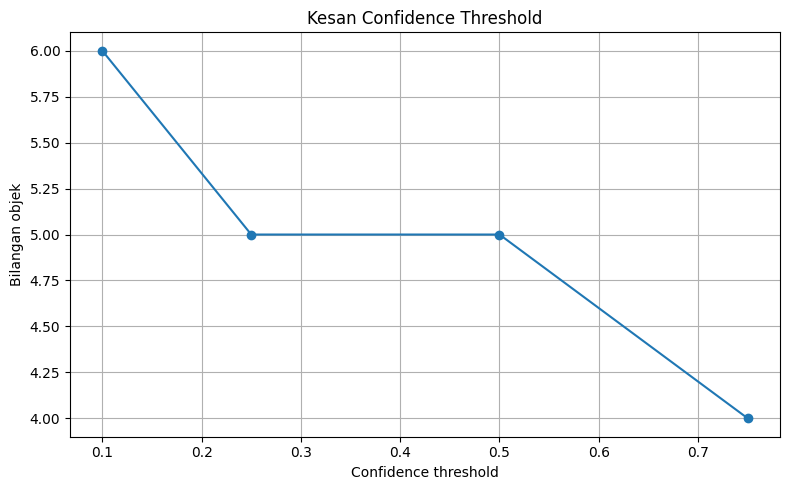

IoU 0.30 -> 5 objek
IoU 0.45 -> 5 objek
IoU 0.60 -> 5 objek
IoU 0.75 -> 5 objek
KIRAAN OBJEK MENGIKUT KELAS
person         : 4
bus            : 1

Jumlah keseluruhan: 5


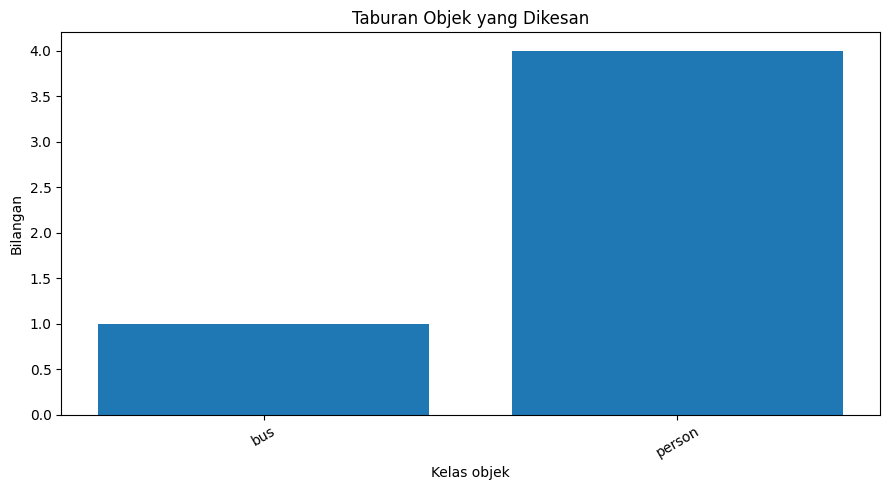

Sila muat naik fail test-video.avi


Saving test-video.avi to test-video.avi
Frame diproses : 120
Video disimpan : /content/kv_tron_detection_output.mp4


JUMLAH DETECTION SEPANJANG VIDEO
person         : 595
truck          : 120
car            : 120
dog            : 36
PENGESAHAN 5 FIX ME
LULUS - FIX ME 1 - CONF_THRESHOLD
LULUS - FIX ME 2 - IOU_THRESHOLD
LULUS - FIX ME 3 - CONF_VALUES
LULUS - FIX ME 4 - record["nama_kelas"]
LULUS - FIX ME 5 - MAX_FRAMES

PENGESAHAN AKTIVITI
LULUS - Tahap 1 - Sistem sedia
LULUS - Tahap 2 - Latihan model
LULUS - Tahap 3 - Pengesanan imej
LULUS - Tahap 4 - Eksperimen threshold
LULUS - Tahap 5 - Kiraan objek
LULUS - Tahap 6 - Video berjaya

[LULUS] Semua ralat dan aktiviti Amali 2 telah diselesaikan.


In [1]:
# %% [markdown]
# # DKA3223 - Pentaksiran Berterusan Amali 2
# ## Simulasi Object Detection Menggunakan YOLO11n
#
# **Nama:** ISI NAMA CALON
# **Angka Giliran:** ISI ANGKA GILIRAN
#
# **Hak Cipta dan Perlindungan Data:** Dataset visual hendaklah digunakan hanya
# untuk tujuan pembelajaran yang dibenarkan. Sebarang imej atau video yang
# mengandungi maklumat peribadi perlu diurus mengikut prinsip perlindungan data.
#
# **Etika Pembangunan AI:** Model pengawasan visual ini dibangunkan secara
# bertanggungjawab dengan mengambil kira privasi, ketepatan, keadilan,
# keselamatan dan batasan ramalan model.

# %%
# =============================================================================
# LANGKAH 1 - PENYEDIAAN PERSEKITARAN DAN SEMAKAN GPU/CPU
# =============================================================================

import importlib.util
import os
import random
import subprocess
import sys
import urllib.request
from collections import Counter
from pathlib import Path


def install_required_packages():
    """Pasang pustaka yang diperlukan jika Ultralytics belum tersedia."""
    if importlib.util.find_spec("ultralytics") is None:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", "ultralytics"]
        )


install_required_packages()

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from IPython.display import Video, display
from ultralytics import YOLO

try:
    from google.colab import files
except ImportError:
    files = None


# Tetapan reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

DEVICE = 0 if torch.cuda.is_available() else "cpu"

print("=" * 60)
print("MAKLUMAT SISTEM")
print("=" * 60)
print("PyTorch       :", torch.__version__)
print("CUDA tersedia :", torch.cuda.is_available())
print("Peranti YOLO  :", DEVICE)

if torch.cuda.is_available():
    print("Nama GPU      :", torch.cuda.get_device_name(0))
else:
    print("Nama GPU      : Tiada - pemprosesan menggunakan CPU")


# %%
# =============================================================================
# LANGKAH 2 - MUATKAN DAN LATIH MODEL YOLO11n
# =============================================================================

MODEL_NAME = "yolo11n.pt"
DATASET_YAML = "coco8.yaml"
EPOCHS = 5
IMAGE_SIZE = 640
BATCH_SIZE = 8

model = YOLO(MODEL_NAME)

print("Model pralatih berjaya dimuatkan:", MODEL_NAME)
print("Dataset latihan                 :", DATASET_YAML)
print("Epochs                          :", EPOCHS)
print("Image size                      :", IMAGE_SIZE)
print("Batch size                      :", BATCH_SIZE)

# coco8.yaml ialah dataset kecil rasmi Ultralytics yang sesuai untuk simulasi.
# Tukar DATASET_YAML kepada /content/nama_dataset/data.yaml jika pensyarah
# membekalkan dataset berlabel yang lain.
training_results = model.train(
    data=DATASET_YAML,
    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    seed=SEED,
    deterministic=True,
    project="/content/runs/detect" if Path("/content").exists() else "runs/detect",
    name="amali2_yolo11n",
    exist_ok=True,
    verbose=True,
)

# Gunakan pemberat terbaik daripada latihan untuk inferens.
best_model_path = Path(model.trainer.best)
if not best_model_path.exists():
    raise FileNotFoundError(f"Pemberat terbaik tidak ditemui: {best_model_path}")

model = YOLO(str(best_model_path))
print("Model terbaik untuk inferens:", best_model_path)
print("Jumlah kelas               :", len(model.names))


# %%
# =============================================================================
# LANGKAH 3 - SEDIAKAN IMEJ UJIAN
# =============================================================================

GUNA_IMEJ_SENDIRI = False
IMAGE_PATH = "/content/bus.jpg" if Path("/content").exists() else "bus.jpg"

if GUNA_IMEJ_SENDIRI:
    if files is None:
        raise RuntimeError(
            "Fungsi muat naik Google Colab tidak tersedia. "
            "Tetapkan IMAGE_PATH kepada fail imej tempatan."
        )

    uploaded = files.upload()
    if not uploaded:
        raise RuntimeError("Tiada imej dimuat naik.")
    IMAGE_PATH = next(iter(uploaded.keys()))
else:
    image_url = "https://ultralytics.com/images/bus.jpg"
    if not os.path.exists(IMAGE_PATH):
        urllib.request.urlretrieve(image_url, IMAGE_PATH)

if not os.path.exists(IMAGE_PATH):
    raise FileNotFoundError(f"Imej tidak ditemui: {IMAGE_PATH}")

image_rgb = Image.open(IMAGE_PATH).convert("RGB")
print("Imej:", IMAGE_PATH)
print("Saiz :", image_rgb.size)
display(image_rgb)


# %%
# =============================================================================
# LANGKAH 4 - INFERENS IMEJ DAN EKSTRAKSI BOUNDING BOX
# =============================================================================

# FIX ME 1 telah dibaiki: tetapkan nilai confidence antara 0 dan 1.
CONF_THRESHOLD = 0.25

if not isinstance(CONF_THRESHOLD, (int, float)):
    raise TypeError("CONF_THRESHOLD mestilah nombor.")
if not 0 < CONF_THRESHOLD <= 1:
    raise ValueError("CONF_THRESHOLD mestilah antara 0 dan 1.")

# FIX ME 2 telah dibaiki: tetapkan nilai IoU antara 0 dan 1.
IOU_THRESHOLD = 0.45

if not isinstance(IOU_THRESHOLD, (int, float)):
    raise TypeError("IOU_THRESHOLD mestilah nombor.")
if not 0 < IOU_THRESHOLD <= 1:
    raise ValueError("IOU_THRESHOLD mestilah antara 0 dan 1.")

results = model.predict(
    source=IMAGE_PATH,
    conf=CONF_THRESHOLD,
    iou=IOU_THRESHOLD,
    imgsz=IMAGE_SIZE,
    device=DEVICE,
    verbose=False,
)

result = results[0]

print("Confidence threshold:", CONF_THRESHOLD)
print("IoU threshold       :", IOU_THRESHOLD)
print("Jumlah objek        :", len(result.boxes))

annotated_bgr = result.plot()
annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(annotated_rgb)
plt.axis("off")
plt.title("Hasil Pengesanan Objek Menggunakan YOLO11n")
plt.tight_layout()
plt.show()

detection_records = []

print("=" * 95)
print("BUTIRAN PENGESANAN")
print("=" * 95)

for number, box in enumerate(result.boxes, start=1):
    class_id = int(box.cls[0].item())
    class_name = model.names[class_id]
    confidence = float(box.conf[0].item())
    x1, y1, x2, y2 = box.xyxy[0].tolist()

    record = {
        "nombor": number,
        "id_kelas": class_id,
        "nama_kelas": class_name,
        "keyakinan": confidence,
        "bounding_box": [x1, y1, x2, y2],
    }
    detection_records.append(record)

    print(
        f"{number:02d}. {class_name:<12} | "
        f"keyakinan={confidence:.2%} | "
        f"kotak=({x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f})"
    )

if not detection_records:
    print("Tiada objek dikesan. Cuba gunakan confidence yang lebih rendah.")


# %%
# =============================================================================
# LANGKAH 5 - EKSPERIMEN CONFIDENCE DAN IoU THRESHOLD
# =============================================================================

# FIX ME 3 telah dibaiki: empat nilai confidence untuk perbandingan.
CONF_VALUES = [0.10, 0.25, 0.50, 0.75]

if not isinstance(CONF_VALUES, list) or len(CONF_VALUES) != 4:
    raise ValueError("CONF_VALUES mestilah senarai yang mengandungi empat nilai.")
if not all(isinstance(value, (int, float)) for value in CONF_VALUES):
    raise TypeError("Semua nilai dalam CONF_VALUES mestilah nombor.")
if not all(0 < value <= 1 for value in CONF_VALUES):
    raise ValueError("Semua nilai CONF_VALUES mestilah antara 0 dan 1.")

conf_summary = []

for conf_value in CONF_VALUES:
    test_result = model.predict(
        source=IMAGE_PATH,
        conf=conf_value,
        iou=IOU_THRESHOLD,
        imgsz=IMAGE_SIZE,
        device=DEVICE,
        verbose=False,
    )[0]

    total = len(test_result.boxes)
    conf_summary.append((conf_value, total))
    print(f"Confidence {conf_value:.2f} -> {total} objek")

x_conf = [item[0] for item in conf_summary]
y_conf = [item[1] for item in conf_summary]

plt.figure(figsize=(8, 5))
plt.plot(x_conf, y_conf, marker="o")
plt.xlabel("Confidence threshold")
plt.ylabel("Bilangan objek")
plt.title("Kesan Confidence Threshold")
plt.grid(True)
plt.tight_layout()
plt.show()

IOU_VALUES = [0.30, 0.45, 0.60, 0.75]
iou_summary = []

for iou_value in IOU_VALUES:
    test_result = model.predict(
        source=IMAGE_PATH,
        conf=CONF_THRESHOLD,
        iou=iou_value,
        imgsz=IMAGE_SIZE,
        device=DEVICE,
        verbose=False,
    )[0]

    total = len(test_result.boxes)
    iou_summary.append((iou_value, total))
    print(f"IoU {iou_value:.2f} -> {total} objek")


# %%
# =============================================================================
# LANGKAH 6 - PENGIRAAN OBJEK AUTOMATIK
# =============================================================================

# FIX ME 4 telah dibaiki: medan kelas yang betul dalam detection_records.
OBJECT_CLASS_FIELD = "nama_kelas"

if OBJECT_CLASS_FIELD not in {"nama_kelas"}:
    raise ValueError('Medan yang betul ialah "nama_kelas".')

object_counter = Counter(
    record[OBJECT_CLASS_FIELD] for record in detection_records
)

print("=" * 45)
print("KIRAAN OBJEK MENGIKUT KELAS")
print("=" * 45)

if object_counter:
    for class_name, count in object_counter.most_common():
        print(f"{class_name:<15}: {count}")
else:
    print("Tiada objek untuk dikira.")

print("\nJumlah keseluruhan:", sum(object_counter.values()))

if object_counter:
    labels = list(object_counter.keys())
    counts = list(object_counter.values())

    plt.figure(figsize=(9, 5))
    plt.bar(labels, counts)
    plt.xlabel("Kelas objek")
    plt.ylabel("Bilangan")
    plt.title("Taburan Objek yang Dikesan")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


# %%
# =============================================================================
# LANGKAH 7 - INFERENS VIDEO
# =============================================================================

VIDEO_PATH = "/content/test-video.avi" if Path("/content").exists() else "test-video.avi"
OUTPUT_VIDEO_PATH = (
    "/content/kv_tron_detection_output.mp4"
    if Path("/content").exists()
    else "kv_tron_detection_output.mp4"
)

if not os.path.exists(VIDEO_PATH):
    if files is None:
        raise FileNotFoundError(
            f"Video tidak ditemui: {VIDEO_PATH}. Letakkan test-video.avi "
            "dalam folder semasa."
        )

    print("Sila muat naik fail test-video.avi")
    uploaded_video = files.upload()
    if "test-video.avi" not in uploaded_video:
        raise FileNotFoundError("Fail test-video.avi tidak dimuat naik.")

# FIX ME 5 telah dibaiki: proses maksimum 120 frame.
MAX_FRAMES = 120

if not isinstance(MAX_FRAMES, int) or MAX_FRAMES <= 0:
    raise ValueError("MAX_FRAMES mestilah nombor bulat lebih besar daripada 0.")

VIDEO_CONF = 0.30
VIDEO_IOU = 0.45

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise RuntimeError("Video tidak dapat dibuka.")

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

if fps <= 0:
    fps = 25.0

writer = cv2.VideoWriter(
    OUTPUT_VIDEO_PATH,
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height),
)

if not writer.isOpened():
    cap.release()
    raise RuntimeError("Fail video output tidak dapat dicipta.")

frame_count = 0
video_object_counter = Counter()

while cap.isOpened() and frame_count < MAX_FRAMES:
    success, frame = cap.read()
    if not success:
        break

    frame_result = model.predict(
        source=frame,
        conf=VIDEO_CONF,
        iou=VIDEO_IOU,
        imgsz=IMAGE_SIZE,
        device=DEVICE,
        verbose=False,
    )[0]

    for box in frame_result.boxes:
        class_id = int(box.cls[0].item())
        class_name = model.names[class_id]
        video_object_counter[class_name] += 1

    annotated_frame = frame_result.plot()
    writer.write(annotated_frame)
    frame_count += 1

cap.release()
writer.release()

print("Frame diproses :", frame_count)
print("Video disimpan :", OUTPUT_VIDEO_PATH)

# Tukar video kepada H.264 untuk paparan dalam pelayar
VIDEO_PAPAR = "/content/kv_tron_detection_h264.mp4"

subprocess.run([
    "ffmpeg", "-y",
    "-loglevel", "error",
    "-i", OUTPUT_VIDEO_PATH,
    "-c:v", "libx264",
    "-pix_fmt", "yuv420p",
    "-movflags", "+faststart",
    VIDEO_PAPAR
], check=True)

display(Video(VIDEO_PAPAR, embed=True))

print("=" * 50)
print("JUMLAH DETECTION SEPANJANG VIDEO")
print("=" * 50)

for class_name, count in video_object_counter.most_common(10):
    print(f"{class_name:<15}: {count}")


# %%
# =============================================================================
# LANGKAH 8 - PENGESAHAN AUTOMATIK
# =============================================================================

fix_me_checks = {
    "FIX ME 1 - CONF_THRESHOLD": (
        isinstance(CONF_THRESHOLD, (int, float))
        and 0 < CONF_THRESHOLD <= 1
    ),
    "FIX ME 2 - IOU_THRESHOLD": (
        isinstance(IOU_THRESHOLD, (int, float))
        and 0 < IOU_THRESHOLD <= 1
    ),
    "FIX ME 3 - CONF_VALUES": (
        isinstance(CONF_VALUES, list)
        and len(CONF_VALUES) == 4
        and all(isinstance(value, (int, float)) for value in CONF_VALUES)
        and all(0 < value <= 1 for value in CONF_VALUES)
    ),
    'FIX ME 4 - record["nama_kelas"]': (
        OBJECT_CLASS_FIELD == "nama_kelas"
    ),
    "FIX ME 5 - MAX_FRAMES": (
        isinstance(MAX_FRAMES, int)
        and MAX_FRAMES > 0
    ),
}

checks = {
    "Tahap 1 - Sistem sedia": model is not None,
    "Tahap 2 - Latihan model": best_model_path.exists(),
    "Tahap 3 - Pengesanan imej": len(detection_records) > 0,
    "Tahap 4 - Eksperimen threshold": (
        len(conf_summary) == len(CONF_VALUES)
        and len(iou_summary) == len(IOU_VALUES)
    ),
    "Tahap 5 - Kiraan objek": sum(object_counter.values()) > 0,
    "Tahap 6 - Video berjaya": (
        os.path.exists(OUTPUT_VIDEO_PATH)
        and frame_count > 0
        and frame_count <= MAX_FRAMES
    ),
}

print("=" * 65)
print("PENGESAHAN 5 FIX ME")
print("=" * 65)

for name, passed in fix_me_checks.items():
    print(("LULUS" if passed else "GAGAL"), "-", name)

print("\n" + "=" * 65)
print("PENGESAHAN AKTIVITI")
print("=" * 65)

for name, passed in checks.items():
    print(("LULUS" if passed else "GAGAL"), "-", name)

if all(fix_me_checks.values()) and all(checks.values()):
    print("\n[LULUS] Semua ralat dan aktiviti Amali 2 telah diselesaikan.")
else:
    print("\n[BELUM SELESAI] Semak bahagian yang bertanda GAGAL.")

